# Hierarchical Insect Classifier — Ablation Run D (No Sibling Consistency Loss)

> **Run D**: `LeafSiblingConsistencyLoss` is removed from l4a.
> All other losses (CE on every head, LeafBranchFocalLoss on l4a,
> all 4 HierarchicalCoherenceLoss pairs) are **unchanged**.

CSV facts (hierarchical_labels_v15.csv)
| Property | Value |
|---|---|
| Total samples | 37,588 (train 28,466 / val 7,120 / test 2,002) |
| Species present | 1-3, 5-12, 14-18, 21-31 |
| l1_pest | 0=non-pest, 1=pest |
| l2_role | 0=predator, 1=non-predator, -1=masked |
| l3_pred_type | 0=ladybug-pred, 1=other-pred, -1=masked |
| l3_nonpred_type | 0=ladybug-nonpred, 1=other-nonpred, -1=masked |
| sp_pred_ladybug_common | 0-10 → sp1-3,5-12 (11 classes), -1=masked |
| sp_other_pred | 0-2 → sp14-16 (3 classes), -1=masked |
| sp_nonpred_ladybug | 0-1 → sp17-18 (2 classes), -1=masked |

## Hierarchy
```
level1 (pest/non-pest)
├── 0 → sp21 (non-pest, terminal)
└── 1 → level2 (predator role)
    ├── 0 (predator) → l3a (pred type)
    │   ├── 0 (ladybug-pred) → l4a: 11 classes → sp1,2,3,5,6,7,8,9,10,11,12
    │   └── 1 (other-pred)   → l4b:  3 classes → sp14,15,16
    └── 1 (non-predator) → l3b (nonpred type)
        ├── 0 (ladybug-nonpred) → l4c: 2 classes → sp17,18
        └── 1 (other-nonpred)   → sp22-31 (terminal, merged as sp22
- CSV path updated to v15

In [1]:
!pip install timm scikit-learn pandas pillow tqdm -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


## 1. Dataset

In [2]:
# Cell 2 — Dataset
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms


class HierarchicalInsectDataset(Dataset):
    EXCLUDED_SPECIES = {4, 13, 19}

    def __init__(self, csv_file, split, img_size=224):
        self.df = pd.read_csv(csv_file)
        self.df = self.df[self.df["split"] == split].reset_index(drop=True)
        self.df = self.df[~self.df["species_id"].isin(self.EXCLUDED_SPECIES)].reset_index(drop=True)
        self.split = split

        # No augmentation — identical transform for all splits
        self.transform = transforms.Compose([
            transforms.Resize(int(img_size * 256 / 224)),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)
        labels = {
            "level1":     torch.tensor(row["l1_pest"],                 dtype=torch.long),
            "level2":     torch.tensor(row["l2_role"],                 dtype=torch.long),
            "l3a":        torch.tensor(row["l3_pred_type"],            dtype=torch.long),
            "l3b":        torch.tensor(row["l3_nonpred_type"],         dtype=torch.long),
            "l4a":        torch.tensor(row["sp_pred_ladybug_common"],  dtype=torch.long),
            "l4b":        torch.tensor(row["sp_other_pred"],           dtype=torch.long),
            "l4c":        torch.tensor(row["sp_nonpred_ladybug"],      dtype=torch.long),
            "species_id": torch.tensor(row["species_id"],              dtype=torch.long),
        }
        return img, labels

## 2. Model

In [3]:
# Cell 3 — Model
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm


class StableAdapter(nn.Module):
    def __init__(self, dim, bottleneck=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, bottleneck),
            nn.LayerNorm(bottleneck),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(bottleneck, dim),
            nn.Dropout(dropout),
        )
        self.gate = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        return x + self.gate * self.net(x)


class EfficientNetHierarchicalV5(nn.Module):
    def __init__(self, backbone="efficientnet_b0", pretrained=True, feat_dim=512):
        super().__init__()

        self.backbone = timm.create_model(
            backbone,
            pretrained=pretrained,
            num_classes=0,
            drop_rate=0.2,
            drop_path_rate=0.3,
        )
        in_features = self.backbone.num_features  # 1280 for B0

        self.shared = nn.Sequential(
            nn.Linear(in_features, feat_dim),
            nn.LayerNorm(feat_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )
        for layer in self.shared:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

        self.adapt_l1  = StableAdapter(feat_dim)
        self.adapt_l2  = StableAdapter(feat_dim)
        self.adapt_l3a = StableAdapter(feat_dim)
        self.adapt_l3b = StableAdapter(feat_dim)
        self.adapt_l4b = StableAdapter(feat_dim)
        self.adapt_l4c = StableAdapter(feat_dim)
        self.adapt_l4a = StableAdapter(feat_dim, bottleneck=128, dropout=0.4)

        self.head_level1 = nn.Linear(feat_dim, 2)
        self.head_level2 = nn.Linear(feat_dim, 2)
        self.head_l3a    = nn.Linear(feat_dim, 2)
        self.head_l3b    = nn.Linear(feat_dim, 2)
        self.head_l4a    = nn.Linear(feat_dim, 12)
        self.head_l4b    = nn.Linear(feat_dim, 3)
        self.head_l4c    = nn.Linear(feat_dim, 2)

        for head in [self.head_level1, self.head_level2, self.head_l3a,
                     self.head_l3b, self.head_l4a, self.head_l4b, self.head_l4c]:
            nn.init.xavier_normal_(head.weight)
            nn.init.zeros_(head.bias)

    def forward(self, x, targets=None):
        feats = self.shared(self.backbone(x))
        outputs = {}
        outputs["level1"] = self.head_level1(self.adapt_l1(feats))
        outputs["level2"] = self.head_level2(self.adapt_l2(feats))
        outputs["l3a"]    = self.head_l3a(self.adapt_l3a(feats))
        outputs["l3b"]    = self.head_l3b(self.adapt_l3b(feats))
        outputs["l4a"]    = self.head_l4a(self.adapt_l4a(feats))
        outputs["l4b"]    = self.head_l4b(self.adapt_l4b(feats))
        outputs["l4c"]    = self.head_l4c(self.adapt_l4c(feats))
        return outputs

## 3. Loss

In [4]:
# Cell 4 — Loss  |  Ablation Run D: NO LeafSiblingConsistencyLoss
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np


class LeafBranchFocalLoss(nn.Module):
    def __init__(self, num_classes=12, alpha=0.25, gamma=4.0, ignore_index=-1):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha
        self.gamma = gamma
        self.ignore_index = ignore_index
        self.eps = 1e-8

    def forward(self, logits, targets):
        valid = targets != self.ignore_index
        if valid.sum() == 0:
            return torch.tensor(0.0, device=logits.device, requires_grad=True)
        logits = logits[valid]
        targets = targets[valid]
        targets_one_hot = F.one_hot(targets, num_classes=self.num_classes).float()
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.clamp(torch.exp(log_probs), min=self.eps, max=1.0 - self.eps)
        ce_loss = -targets_one_hot * log_probs
        p_t = torch.clamp((probs * targets_one_hot).sum(dim=1), min=self.eps, max=1.0 - self.eps)
        focal_weight = (1 - p_t) ** self.gamma
        return (self.alpha * focal_weight * ce_loss.sum(dim=1)).mean()


# ── Run D: LeafSiblingConsistencyLoss intentionally removed ──


class StableClassBalancedFocalLoss(nn.Module):
    def __init__(self, samples_per_class, beta=0.999, gamma_minor=2.0,
                 gamma_major=0.5, ignore_index=-1):
        super().__init__()
        samples_per_class = torch.tensor(samples_per_class, dtype=torch.float)
        effective_num = 1.0 - torch.pow(beta, samples_per_class)
        effective_num = torch.clamp(effective_num, min=1e-8)
        weights = (1.0 - beta) / effective_num
        weights = weights / weights.sum()
        self.register_buffer("alpha", weights)
        self.gamma_minor = gamma_minor
        self.gamma_major = gamma_major
        self.ignore_index = ignore_index
        self.eps = 1e-8

    def forward(self, logits, targets):
        valid = targets != self.ignore_index
        if valid.sum() == 0:
            return torch.tensor(0.0, device=logits.device, requires_grad=True)
        logits = logits[valid]
        targets = targets[valid]
        log_probs = F.log_softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=logits.size(1)).float()
        pt = torch.clamp((torch.exp(log_probs) * targets_one_hot).sum(dim=1),
                         min=self.eps, max=1.0 - self.eps)
        gamma = torch.where(targets == 1,
                            torch.full_like(pt, self.gamma_minor),
                            torch.full_like(pt, self.gamma_major))
        alpha = self.alpha.to(targets.device)[targets]
        return (-alpha * (1.0 - pt) ** gamma * torch.log(pt)).mean()


class CardinalityWeightedCELoss(nn.Module):
    def __init__(self, num_classes, ignore_index=-1, label_smoothing=0.1):
        super().__init__()
        self.scale = 1.0 / (num_classes ** 0.5)
        self.ce = nn.CrossEntropyLoss(ignore_index=ignore_index,
                                      label_smoothing=label_smoothing)

    def forward(self, logits, targets):
        return self.scale * self.ce(logits, targets)


class HierarchicalCoherenceLoss(nn.Module):
    def __init__(self, weight=0.1, ignore_index=-1):
        super().__init__()
        self.weight = weight
        self.ignore_index = ignore_index
        self.eps = 1e-8

    def forward(self, child_logits, parent_logits, child_targets, parent_targets):
        valid = (child_targets != self.ignore_index) & (parent_targets != self.ignore_index)
        if valid.sum() == 0:
            return torch.tensor(0.0, device=child_logits.device, requires_grad=True)
        child_logits  = torch.clamp(child_logits[valid],  min=-10.0, max=10.0)
        parent_logits = torch.clamp(parent_logits[valid], min=-10.0, max=10.0)
        child_prob  = torch.clamp(F.softmax(child_logits,  dim=1).max(dim=1)[0],
                                  min=self.eps, max=1.0 - self.eps)
        parent_prob = torch.clamp(F.softmax(parent_logits, dim=1).max(dim=1)[0],
                                  min=self.eps, max=1.0 - self.eps)
        violation = F.relu(child_prob - parent_prob)
        return self.weight * (violation ** 2).mean()


class HierarchicalMultiTaskLoss(nn.Module):
    """Run D: LeafSiblingConsistencyLoss removed. l4a sibling regularisation disabled."""
    def __init__(self, level1_samples, lambda_coherence=0.1,
                 leaf_lambda=0.3, use_leaf_consistency=True):
        super().__init__()

        self.loss_level1    = StableClassBalancedFocalLoss(level1_samples)
        self.loss_level2    = CardinalityWeightedCELoss(2,  label_smoothing=0.1)
        self.loss_l3a       = CardinalityWeightedCELoss(2,  label_smoothing=0.1)
        self.loss_l3b       = CardinalityWeightedCELoss(2,  label_smoothing=0.1)
        self.loss_l4a_ce    = CardinalityWeightedCELoss(12, label_smoothing=0.1)
        self.loss_l4a_focal = LeafBranchFocalLoss(num_classes=12, alpha=0.25, gamma=4.0)
        self.loss_l4b       = CardinalityWeightedCELoss(3,  label_smoothing=0.1)
        self.loss_l4c       = CardinalityWeightedCELoss(2,  label_smoothing=0.1)

        # ── Run D: self.leaf_consistency intentionally removed ──

        self.coherence = HierarchicalCoherenceLoss(weight=lambda_coherence)

        self.task_weights = {
            "level1":    1.0,
            "level2":    0.8,
            "l3a":       0.6,
            "l3b":       0.6,
            "l4a_ce":    0.6,
            "l4a_focal": 0.4,
            "l4b":       0.4,
            "l4c":       0.4,
        }
        self.leaf_lambda = leaf_lambda

    def forward(self, outputs, targets, sibling_mask=None):
        device = next(iter(outputs.values())).device
        total_loss = torch.tensor(0.0, device=device, requires_grad=True)
        loss_components = {}

        l1_loss = self.loss_level1(outputs["level1"], targets["level1"])
        if torch.isfinite(l1_loss):
            total_loss = total_loss + self.task_weights["level1"] * l1_loss
            loss_components["l1"] = l1_loss.item()

        non_pest = targets["level1"] == 0

        def gate(t):
            t = t.clone()
            t[non_pest] = -1
            return t

        t2  = gate(targets["level2"])
        t3a = gate(targets["l3a"])
        t3b = gate(targets["l3b"])
        t4a = gate(targets["l4a"])
        t4b = gate(targets["l4b"])
        t4c = gate(targets["l4c"])

        losses = [
            ("level2",    self.loss_level2(outputs["level2"], t2)),
            ("l3a",       self.loss_l3a(outputs["l3a"], t3a)),
            ("l3b",       self.loss_l3b(outputs["l3b"], t3b)),
            ("l4a_ce",    self.loss_l4a_ce(outputs["l4a"], t4a)),
            ("l4a_focal", self.loss_l4a_focal(outputs["l4a"], t4a)),
            ("l4b",       self.loss_l4b(outputs["l4b"], t4b)),
            ("l4c",       self.loss_l4c(outputs["l4c"], t4c)),
        ]

        for task_name, loss_val in losses:
            if torch.isfinite(loss_val):
                total_loss = total_loss + self.task_weights[task_name] * loss_val
                loss_components[task_name] = loss_val.item()

        # ── Run D: leaf_consistency block intentionally removed ──

        coherence_losses = [
            ("coh_l3a_level2", self.coherence(outputs["l3a"], outputs["level2"], t3a, t2)),
            ("coh_l3b_level2", self.coherence(outputs["l3b"], outputs["level2"], t3b, t2)),
            ("coh_l4a_l3a",   self.coherence(outputs["l4a"], outputs["l3a"],    t4a, t3a)),
            ("coh_l4c_l3b",   self.coherence(outputs["l4c"], outputs["l3b"],    t4c, t3b)),
        ]
        for coh_name, coh_loss in coherence_losses:
            if torch.isfinite(coh_loss):
                total_loss = total_loss + coh_loss
                loss_components[coh_name] = coh_loss.item()

        if not torch.isfinite(total_loss):
            return torch.tensor(0.0, device=device, requires_grad=True), loss_components

        return total_loss, loss_components

    def get_leaf_accuracy_weights(self, current_epoch, total_epochs):
        progress = current_epoch / total_epochs
        if progress < 0.3:
            self.task_weights["l4a_ce"] = 0.7
            self.task_weights["l4a_focal"] = 0.1
        elif progress < 0.7:
            self.task_weights["l4a_ce"] = 0.6
            self.task_weights["l4a_focal"] = 0.3
        else:
            self.task_weights["l4a_ce"] = 0.4
            self.task_weights["l4a_focal"] = 0.5


def create_ladybug_sibling_mask():
    # Run D: mask built but not consumed (no sibling loss to use it)
    num_classes = 12
    mask = torch.zeros(num_classes, num_classes)
    groups = [[0, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10], [11]]
    for group in groups:
        for i in group:
            for j in group:
                if i != j:
                    mask[i, j] = 1.0
    return mask


## 5. Training

In [5]:
# Cell 5 — Training
import os
import torch
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm
from collections import defaultdict
import pandas as pd

# ===================== CONFIG =====================
CSV_PATH     = "/workspace/hierarchical_labels_v15.csv"
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 70
LR           = 1.5e-4
LR_L4A       = LR * 0.5
NUM_WORKERS  = 10
PATIENCE     = 8
WEIGHT_DECAY = 3e-4

DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_DIR = "/workspace/ablation_runD_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

print("🔥 DEVICE:", DEVICE)
print("📋 Ablation Run D — No Sibling Consistency Loss")

# ===================== DATA =====================
df = pd.read_csv(CSV_PATH)

train_ds = HierarchicalInsectDataset(CSV_PATH, split="train", img_size=IMG_SIZE)
val_ds   = HierarchicalInsectDataset(CSV_PATH, split="val",   img_size=IMG_SIZE)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")

all_species_ids = sorted(set(
    22 if 22 <= int(s) <= 31 else int(s)
    for s in df["species_id"].unique()
    if int(s) not in {4, 13, 19}
))

# ===================== MODEL =====================
model = EfficientNetHierarchicalV5(
    backbone="efficientnet_b0", pretrained=True, feat_dim=512
).to(DEVICE)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS =====================
l1_counts = train_ds.df["l1_pest"].value_counts().sort_index().values.tolist()
criterion = HierarchicalMultiTaskLoss(level1_samples=l1_counts, lambda_coherence=0.1)
sibling_mask = create_ladybug_sibling_mask().to(DEVICE)

# ===================== OPTIMIZER =====================
l4a_params    = list(model.adapt_l4a.parameters()) + list(model.head_l4a.parameters())
l4a_param_ids = set(id(p) for p in l4a_params)
other_params  = [p for p in model.parameters() if id(p) not in l4a_param_ids]

optimizer = optim.AdamW(
    [
        {"params": other_params, "lr": LR},
        {"params": l4a_params,   "lr": LR_L4A, "weight_decay": WEIGHT_DECAY * 2},
    ],
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8,
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LR, LR_L4A],
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.15,
    anneal_strategy="cos",
)

use_amp = DEVICE == "cuda"
scaler  = torch.amp.GradScaler("cuda", enabled=use_amp) if use_amp else None

# ===================== HELPERS =====================
def predict_species_id(outputs):
    device = outputs["level1"].device
    B = outputs["level1"].shape[0]
    preds = torch.full((B,), fill_value=-1, dtype=torch.long, device=device)
    l1  = outputs["level1"].argmax(1)
    l2  = outputs["level2"].argmax(1)
    l3a = outputs["l3a"].argmax(1)
    l3b = outputs["l3b"].argmax(1)
    l4a = outputs["l4a"].argmax(1)
    l4b = outputs["l4b"].argmax(1)
    l4c = outputs["l4c"].argmax(1)
    preds[l1 == 0] = 21
    m_low  = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a <= 2)
    preds[m_low]  = l4a[m_low] + 1
    m_high = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a >= 3) & (l4a <= 8)
    preds[m_high] = l4a[m_high] + 2
    m_sp11 = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a == 9)
    preds[m_sp11] = 11
    m_sp12 = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a == 10)
    preds[m_sp12] = 12
    m = (l1 == 1) & (l2 == 0) & (l3a == 1)
    preds[m] = l4b[m] + 14
    m = (l1 == 1) & (l2 == 1) & (l3b == 0)
    preds[m] = l4c[m] + 17
    m = (l1 == 1) & (l2 == 1) & (l3b == 1)
    preds[m] = 22
    return preds


def masked_accuracy(logits, targets):
    mask = targets != -1
    if mask.sum() == 0:
        return None
    with torch.no_grad():
        preds = logits.argmax(dim=1)
        return (preds[mask] == targets[mask]).float().mean().item()


def merge_sp(sid):
    return 22 if 22 <= int(sid) <= 31 else int(sid)

# ===================== TRAINING LOOP =====================
best_val_acc     = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{EPOCHS}  |  LR: {optimizer.param_groups[0]['lr']:.2e}")
    print(f"{'='*60}")

    criterion.get_leaf_accuracy_weights(epoch, EPOCHS)

    # ---- TRAIN ----
    model.train()
    train_loss = 0.0
    train_accs = defaultdict(list)
    tr_correct = tr_total = 0

    for images, labels in tqdm(train_loader, desc="TRAIN", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(images)
            total_loss, loss_components = criterion(outputs, labels, sibling_mask)

        if use_amp:
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()
        train_loss += total_loss.item()

        for head in outputs:
            if head in labels:
                acc = masked_accuracy(outputs[head], labels[head])
                if acc is not None:
                    train_accs[head].append(acc)

        with torch.no_grad():
            sp_pred = predict_species_id(outputs)
            sp_tgt  = labels["species_id"]
            sp_pred_m = torch.tensor([merge_sp(s) for s in sp_pred.cpu().tolist()], device=DEVICE)
            sp_tgt_m  = torch.tensor([merge_sp(s) for s in sp_tgt.cpu().tolist()],  device=DEVICE)
            tr_correct += (sp_pred_m == sp_tgt_m).sum().item()
            tr_total   += sp_tgt.size(0)

    # ---- VALIDATE ----
    model.eval()
    val_loss = 0.0
    val_accs = defaultdict(list)
    va_correct = va_total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="VALID", leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}

            outputs = model(images)
            total_loss, _ = criterion(outputs, labels, sibling_mask)
            val_loss += total_loss.item()

            for head in outputs:
                if head in labels:
                    acc = masked_accuracy(outputs[head], labels[head])
                    if acc is not None:
                        val_accs[head].append(acc)

            sp_pred = predict_species_id(outputs)
            sp_tgt  = labels["species_id"]
            sp_pred_m = torch.tensor([merge_sp(s) for s in sp_pred.cpu().tolist()], device=DEVICE)
            sp_tgt_m  = torch.tensor([merge_sp(s) for s in sp_tgt.cpu().tolist()],  device=DEVICE)
            va_correct += (sp_pred_m == sp_tgt_m).sum().item()
            va_total   += sp_tgt.size(0)

    # ---- REPORT ----
    avg_tr_loss = train_loss / len(train_loader)
    avg_va_loss = val_loss   / len(val_loader)
    tr_sp_acc   = tr_correct / tr_total if tr_total else 0
    va_sp_acc   = va_correct / va_total if va_total else 0

    print(f"  Train Loss: {avg_tr_loss:.4f}  |  Val Loss: {avg_va_loss:.4f}")
    print(f"  Train Species Acc: {tr_sp_acc:.4f}  |  Val Species Acc: {va_sp_acc:.4f}")
    print(f"  Per-head accuracies (val):")
    for head in sorted(val_accs):
        t = np.mean(train_accs[head]) if train_accs[head] else 0.0
        v = np.mean(val_accs[head])   if val_accs[head]   else 0.0
        print(f"    {head:<10} | train {t:.4f}  val {v:.4f}  gap {t-v:+.4f}")

    # ---- CHECKPOINT ----
    if va_sp_acc > best_val_acc:
        best_val_acc     = va_sp_acc
        patience_counter = 0
        torch.save({
            "epoch":            epoch,
            "model_state_dict": model.state_dict(),
            "val_species_acc":  va_sp_acc,
            "val_loss":         avg_va_loss,
        }, os.path.join(SAVE_DIR, "best_model.pth"))
        print(f"  ✅ Saved best model (val species acc: {va_sp_acc:.4f})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("\n🛑 Early stopping triggered.")
            break

print(f"\n🏆 Done. Best val species accuracy: {best_val_acc:.4f}")

🔥 DEVICE: cuda
📋 Ablation Run D — No Sibling Consistency Loss
Train: 28,486 | Val: 7,100
Trainable params: 5,206,684

Epoch 1/70  |  LR: 6.00e-06


  Train Loss: 2.0494  |  Val Loss: 0.7784
  Train Species Acc: 0.1346  |  Val Species Acc: 0.3349
  Per-head accuracies (val):
    l3a        | train 0.6934  val 0.8740  gap -0.1806
    l3b        | train 0.6992  val 0.8699  gap -0.1706
    l4a        | train 0.1338  val 0.2367  gap -0.1029
    l4b        | train 0.4836  val 0.7509  gap -0.2673
    l4c        | train 0.5852  val 0.7534  gap -0.1682
    level1     | train 0.8418  val 0.9658  gap -0.1240
    level2     | train 0.7310  val 0.8055  gap -0.0745
  ✅ Saved best model (val species acc: 0.3349)

Epoch 2/70  |  LR: 9.20e-06


  Train Loss: 1.4900  |  Val Loss: 0.5894
  Train Species Acc: 0.3475  |  Val Species Acc: 0.5851
  Per-head accuracies (val):
    l3a        | train 0.8440  val 0.9319  gap -0.0880
    l3b        | train 0.8577  val 0.9456  gap -0.0880
    l4a        | train 0.2733  val 0.5267  gap -0.2534
    l4b        | train 0.7446  val 0.8866  gap -0.1420
    l4c        | train 0.8021  val 0.9017  gap -0.0996
    level1     | train 0.9596  val 0.9813  gap -0.0217
    level2     | train 0.8042  val 0.8749  gap -0.0706
  ✅ Saved best model (val species acc: 0.5851)

Epoch 3/70  |  LR: 1.85e-05


  Train Loss: 1.1649  |  Val Loss: 0.4920
  Train Species Acc: 0.5452  |  Val Species Acc: 0.7213
  Per-head accuracies (val):
    l3a        | train 0.9062  val 0.9539  gap -0.0477
    l3b        | train 0.9312  val 0.9752  gap -0.0440
    l4a        | train 0.4902  val 0.6899  gap -0.1997
    l4b        | train 0.8611  val 0.9302  gap -0.0691
    l4c        | train 0.8923  val 0.9467  gap -0.0544
    level1     | train 0.9799  val 0.9887  gap -0.0089
    level2     | train 0.8610  val 0.9147  gap -0.0537
  ✅ Saved best model (val species acc: 0.7213)

Epoch 4/70  |  LR: 3.31e-05


  Train Loss: 0.9700  |  Val Loss: 0.4357
  Train Species Acc: 0.6684  |  Val Species Acc: 0.7968
  Per-head accuracies (val):
    l3a        | train 0.9368  val 0.9700  gap -0.0332
    l3b        | train 0.9577  val 0.9807  gap -0.0230
    l4a        | train 0.6276  val 0.7698  gap -0.1422
    l4b        | train 0.9134  val 0.9553  gap -0.0419
    l4c        | train 0.9436  val 0.9559  gap -0.0123
    level1     | train 0.9894  val 0.9920  gap -0.0025
    level2     | train 0.9005  val 0.9388  gap -0.0383
  ✅ Saved best model (val species acc: 0.7968)

Epoch 5/70  |  LR: 5.17e-05


...

  Train Loss: 0.5311  |  Val Loss: 0.3600
  Train Species Acc: 0.9851  |  Val Species Acc: 0.9056
  Per-head accuracies (val):
    l3a        | train 0.9977  val 0.9898  gap +0.0079
    l3b        | train 0.9990  val 0.9797  gap +0.0193
    l4a        | train 0.9859  val 0.9017  gap +0.0842
    l4b        | train 0.9968  val 0.9749  gap +0.0219
    l4c        | train 0.9992  val 0.9743  gap +0.0250
    level1     | train 0.9994  val 0.9955  gap +0.0039
    level2     | train 0.9948  val 0.9668  gap +0.0280
  ⏳ No improvement (4/8)

Epoch 20/70  |  LR: 1.43e-04


  Train Loss: 0.5329  |  Val Loss: 0.3529
  Train Species Acc: 0.9842  |  Val Species Acc: 0.9101
  Per-head accuracies (val):
    l3a        | train 0.9972  val 0.9872  gap +0.0101
    l3b        | train 0.9994  val 0.9837  gap +0.0157
    l4a        | train 0.9861  val 0.9054  gap +0.0807
    l4b        | train 0.9972  val 0.9777  gap +0.0195
    l4c        | train 0.9957  val 0.9651  gap +0.0306
    level1     | train 0.9996  val 0.9975  gap +0.0021
    level2     | train 0.9940  val 0.9683  gap +0.0257
  ⏳ No improvement (5/8)

Epoch 21/70  |  LR: 1.41e-04


  Train Loss: 0.5116  |  Val Loss: 0.3469
  Train Species Acc: 0.9865  |  Val Species Acc: 0.9101
  Per-head accuracies (val):
    l3a        | train 0.9971  val 0.9893  gap +0.0078
    l3b        | train 0.9991  val 0.9864  gap +0.0127
    l4a        | train 0.9894  val 0.9066  gap +0.0828
    l4b        | train 0.9982  val 0.9749  gap +0.0233
    l4c        | train 0.9988  val 0.9761  gap +0.0227
    level1     | train 0.9993  val 0.9976  gap +0.0017
    level2     | train 0.9949  val 0.9657  gap +0.0292
  ⏳ No improvement (6/8)

Epoch 22/70  |  LR: 1.39e-04


  Train Loss: 0.5113  |  Val Loss: 0.3516
  Train Species Acc: 0.9872  |  Val Species Acc: 0.9100
  Per-head accuracies (val):
    l3a        | train 0.9984  val 0.9891  gap +0.0092
    l3b        | train 0.9993  val 0.9851  gap +0.0142
    l4a        | train 0.9884  val 0.9078  gap +0.0806
    l4b        | train 0.9976  val 0.9782  gap +0.0194
    l4c        | train 0.9953  val 0.9779  gap +0.0173
    level1     | train 0.9996  val 0.9952  gap +0.0044
    level2     | train 0.9952  val 0.9673  gap +0.0279
  ⏳ No improvement (7/8)

Epoch 23/70  |  LR: 1.37e-04


  Train Loss: 0.5099  |  Val Loss: 0.3506
  Train Species Acc: 0.9876  |  Val Species Acc: 0.9100
  Per-head accuracies (val):
    l3a        | train 0.9983  val 0.9875  gap +0.0108
    l3b        | train 0.9993  val 0.9864  gap +0.0129
    l4a        | train 0.9876  val 0.9026  gap +0.0850
    l4b        | train 0.9977  val 0.9763  gap +0.0214
    l4c        | train 0.9996  val 0.9669  gap +0.0327
    level1     | train 0.9996  val 0.9970  gap +0.0026
    level2     | train 0.9958  val 0.9670  gap +0.0288
  ⏳ No improvement (8/8)

🛑 Early stopping triggered.

🏆 Done. Best val species accuracy: 0.9154


## 6. Evaluation (Test Split)

Loaded epoch 15  (saved val acc: 0.9154)


TEST: 100%|██████████| 65/65 [00:12<00:00,  5.41it/s]



TEST RESULTS — per species
Species              Acc  Precision   Recall       F1   Correct   Total
--------------------------------------------------------------------------------
sp1               0.8571     0.8571   0.8571   0.8571        84      98
sp2               0.9412     0.7901   0.9412   0.8591        64      68
sp3               0.9589     0.9211   0.9589   0.9396        70      73
sp5               0.7763     0.8551   0.7763   0.8138        59      76
sp6               0.7468     0.7763   0.7468   0.7613        59      79
sp7               0.8421     0.8889   0.8421   0.8649        64      76
sp8               0.8421     0.7356   0.8421   0.7853        64      76
sp9               0.7538     0.8909   0.7538   0.8167        49      65
sp10              0.8769     0.7600   0.8769   0.8143        57      65
sp11              0.7191     0.8649   0.7191   0.7853        64      89
sp12              0.7091     0.5493   0.7091   0.6190        39      55
sp14              0.8588   

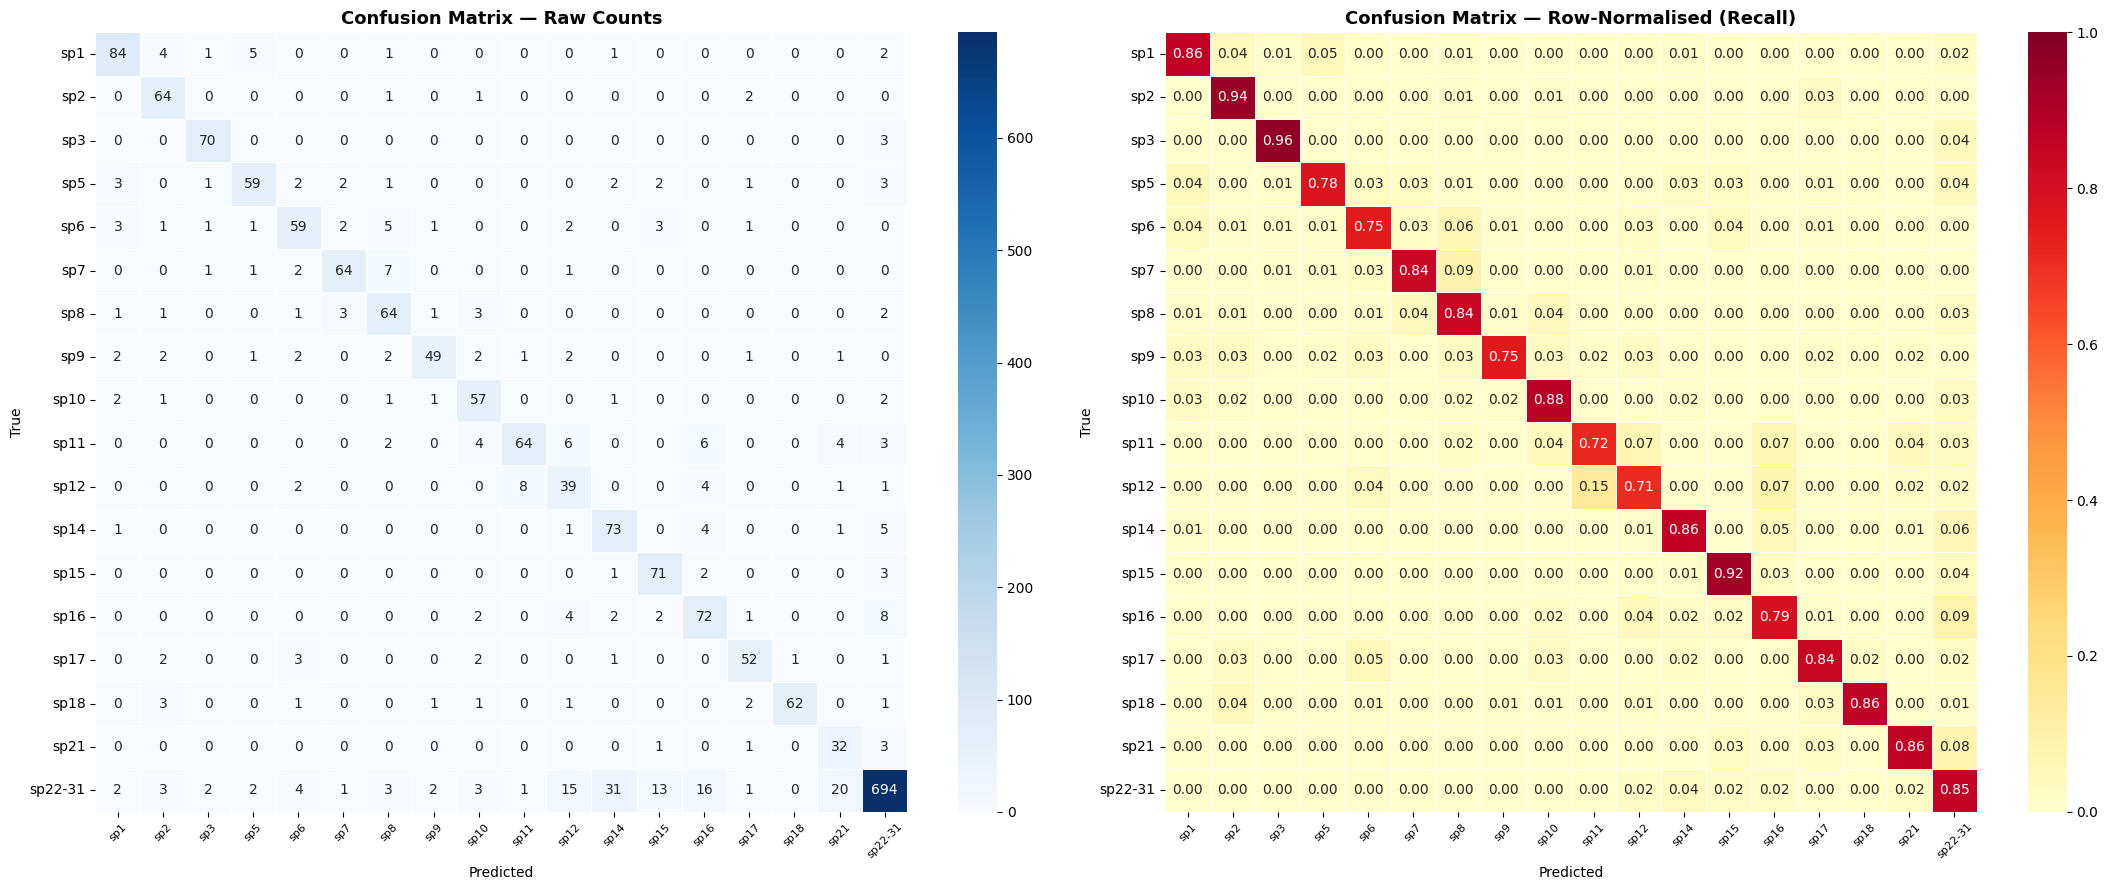

In [6]:
# Cell 6 — Evaluation (Test Split)
import torch
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef,
    balanced_accuracy_score,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

CHECKPOINT_PATH = "/workspace/ablation_runD_checkpoints/best_model.pth"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SPECIES_LABEL_MAP = {
    1: "sp1",  2: "sp2",  3: "sp3",  5: "sp5",  6: "sp6",
    7: "sp7",  8: "sp8",  9: "sp9",  10: "sp10", 11: "sp11",
    12: "sp12", 14: "sp14", 15: "sp15", 16: "sp16",
    17: "sp17", 18: "sp18", 21: "sp21", 22: "sp22-31",
}
ALL_SPECIES   = sorted(SPECIES_LABEL_MAP.keys())
SPECIES_NAMES = [SPECIES_LABEL_MAP[s] for s in ALL_SPECIES]

test_ds     = HierarchicalInsectDataset(CSV_PATH, split="test", img_size=IMG_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True)

model_eval = EfficientNetHierarchicalV5(
    backbone="efficientnet_b0", pretrained=False, feat_dim=512
).to(DEVICE)
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model_eval.load_state_dict(ckpt["model_state_dict"])
model_eval.eval()
print(f"Loaded epoch {ckpt['epoch']}  (saved val acc: {ckpt['val_species_acc']:.4f})")

all_preds   = []
all_targets = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="TEST"):
        images = images.to(DEVICE, non_blocking=True)
        labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}
        outputs  = model_eval(images)
        sp_pred  = predict_species_id(outputs).cpu().numpy()
        sp_tgt   = labels["species_id"].cpu().numpy()
        for pred, tgt in zip(sp_pred, sp_tgt):
            all_targets.append(merge_sp(tgt))
            all_preds.append(merge_sp(pred) if pred != -1 else -1)

all_targets = np.array(all_targets)
all_preds   = np.array(all_preds)

# Per-species table
print(f"\n{'='*80}\nTEST RESULTS — per species\n{'='*80}")
print(f"{'Species':<16} {'Acc':>7} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Correct':>9} {'Total':>7}")
print(f"{'-'*80}")

total_correct = total_samples = 0
per_species_acc = {}

for sid in ALL_SPECIES:
    mask  = all_targets == sid
    total = mask.sum()
    if total == 0:
        continue
    correct = (all_preds[mask] == sid).sum()
    acc     = correct / total
    y_true_bin = (all_targets == sid).astype(int)
    y_pred_bin = (all_preds   == sid).astype(int)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec  = recall_score(y_true_bin,    y_pred_bin, zero_division=0)
    f1   = f1_score(y_true_bin,        y_pred_bin, zero_division=0)
    flag = " ⚠️" if acc < 0.70 else ""
    print(f"{SPECIES_LABEL_MAP[sid]:<16} {acc:>7.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} {correct:>9} {total:>7}{flag}")
    per_species_acc[sid] = acc
    total_correct += correct
    total_samples += total

overall_acc = total_correct / total_samples if total_samples else 0.0
print(f"{'-'*80}\n{'OVERALL':<16} {overall_acc:>7.4f}")

# Aggregate metrics
valid = all_preds != -1
y_true, y_pred = all_targets[valid], all_preds[valid]
labels_present = [s for s in ALL_SPECIES if s in y_true]

print(f"\n{'='*80}\nAGGREGATE METRICS\n{'='*80}")
print(f"  Overall Accuracy   : {overall_acc:.4f}")
print(f"  Balanced Accuracy  : {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"  Macro F1           : {f1_score(y_true, y_pred, labels=labels_present, average='macro', zero_division=0):.4f}")
print(f"  Weighted F1        : {f1_score(y_true, y_pred, labels=labels_present, average='weighted', zero_division=0):.4f}")
print(f"  Cohen Kappa        : {cohen_kappa_score(y_true, y_pred):.4f}")
print(f"  MCC                : {matthews_corrcoef(y_true, y_pred):.4f}")

# Confusion matrix
cm      = confusion_matrix(y_true, y_pred, labels=labels_present)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
target_names = [SPECIES_LABEL_MAP[s] for s in labels_present]

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
sns.heatmap(cm,      ax=axes[0], xticklabels=target_names, yticklabels=target_names,
            annot=True, fmt="d",    cmap="Blues",   linewidths=0.4)
sns.heatmap(cm_norm, ax=axes[1], xticklabels=target_names, yticklabels=target_names,
            annot=True, fmt=".2f",  cmap="YlOrRd",  vmin=0, vmax=1, linewidths=0.4)
axes[0].set_title("Confusion Matrix — Raw Counts",           fontsize=13, fontweight="bold")
axes[1].set_title("Confusion Matrix — Row-Normalised (Recall)", fontsize=13, fontweight="bold")
for ax in axes:
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.savefig("/workspace/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()